# Taxi Problem

- Logistic Example: pickup + routing + dropoff

In [1]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt

Taxi environment download

In [ ]:
env = gym.make('Taxi-v3', render_mode='human')

- Number of possible states (oberservation_space)
- Number of action that agent can do

$$
Action ={south, north, east, west, pickup, dropoff}
$$
represent in 0,1,2,3,4,5

In [3]:
state_size = env.observation_space.n
action_size = env.action_space.n

print(f"States: {state_size}")
print(f"Actions: {action_size}")

States: 500
Actions: 6


### Q-table

$$
Q(s,a)
$$

Meaning: 
- Quality of action a in state s
- If stand on $s_1$ state and do $s_1$ action -> approximate the reward in the future

In [4]:
Q = np.zeros((state_size, action_size))
display(Q)

array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.]])

### Q-Learning Update Rule

$$
Q(s,a) \leftarrow Q(s,a) + \alpha \left[
r + \gamma \max_{a'} Q(s',a') - Q(s,a)
\right]
$$

In [5]:
alpha = 0.1
gamma = 0.9
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01

episodes = 10000
max_steps = 200

rewards = []

- Episode loop
-   └─ Step loop
-        └─ Update Q-table

### Example Training Update (in 1 episode)

step1
state=10
action=2
reward=-1
→ update Q

step2
state=15
action=0
reward=-1
→ update Q

step3
state=22
action=4
reward=0
→ update Q

step4
state=100
action=5
reward=20
→ update Q

In [6]:
for episode in range(episodes):
    state, _ = env.reset()
    total_reward = 0
    
    for step in range(max_steps):
        
        # epsilon-greedy action policy
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state])
        
        next_state, reward, terminated, truncated, _ = env.step(action)
        
        # Q-Learning update
        Q[state, action] = Q[state, action] + alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        ) 
        state = next_state
        total_reward += reward
        
        if terminated or truncated:
            break
    rewards.append(total_reward)
    
    # decay exploration
    if epsilon > epsilon_min:
        epsilon *= epsilon_decay

print("Training Completed")
print("Average Reward:", np.mean(rewards[-100:]))

Training Completed
Average Reward: 7.54


+ Episode
+   └── Step
+           └── Agent action
+           └── Environment response
+            └── Learning update

In [11]:
len(rewards)

10000

## Evaluation Phase

Agent Run like greedy policy

concept: use Q-table that already be trained for agent use on environment (reset env)

In [7]:
state, _ = env.reset()
done = False
env.render()

while not done:
    action = np.argmax(Q[state])
    next_state, reward, terminated, truncated, _ = env.step(action)
    env.render()
    state = next_state
    done = terminated or truncated

c:\Users\BM MONEY\miniconda3\Lib\site-packages\gymnasium\envs\toy_text\taxi.py:443: UserWarning: WARN: You are calling render method without specifying any render mode. You can specify the render_mode at initialization, e.g. gym.make("Taxi-v3", render_mode="rgb_array")
  gym.logger.warn(


## Reward Visualization

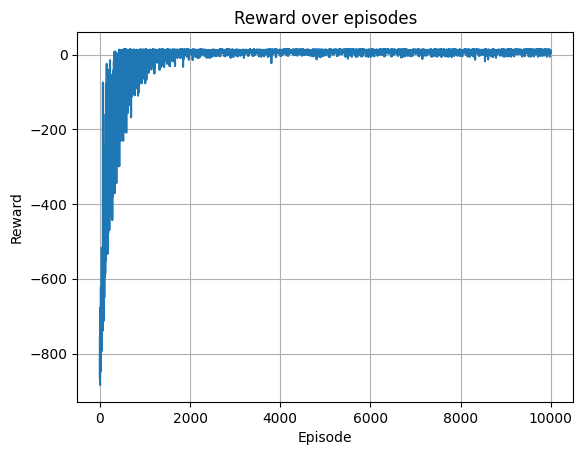

In [9]:
plt.plot(rewards)
plt.title("Reward over episodes")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)  
plt.show()